# European Bank Customer Churn Prediction & Explainability

## Objective

The objective of this project is to develop a machine learning solution that can:

- Predict customer churn accurately
- Generate individual customer churn probability scores
- Identify key drivers of customer churn
- Reduce false positive churn predictions
- Improve model interpretability using explainable AI
- Segment customers based on churn risk
- Provide actionable business recommendations for customer retention

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

Load Dataset

In [2]:
df = pd.read_csv('/Users/vardaraj/Downloads/European_Bank.csv')
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Check Dimensions

In [3]:
df.shape

(10000, 14)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [5]:
df.describe()

,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [6]:
df.columns.tolist()

['Year',
 'CustomerId',
 'Surname',
 'CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited']

In [7]:
df.nunique()

Year                   1
CustomerId         10000
Surname             2932
CreditScore          460
Geography              3
Gender                 2
Age                   70
Tenure                11
Balance             6382
NumOfProducts          4
HasCrCard              2
IsActiveMember         2
EstimatedSalary     9999
Exited                 2
dtype: int64

In [8]:
missing_values =df.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

In [9]:
print('Number of duplicate rows:', df.duplicated().sum())

Number of duplicate rows: 0


In [10]:
duplicates = df[df.duplicated(keep=False)]

print("Number of duplicate rows:", len(duplicates))
duplicates

Number of duplicate rows: 0


,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited


In [11]:
df = df.drop_duplicates()
print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (10000, 14)


In [12]:
print(df['Exited'].value_counts())

Exited
0    7963
1    2037
Name: count, dtype: int64


In [13]:
churn_percentage = df['Exited'].value_counts(normalize=True) * 100
print(churn_percentage)

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


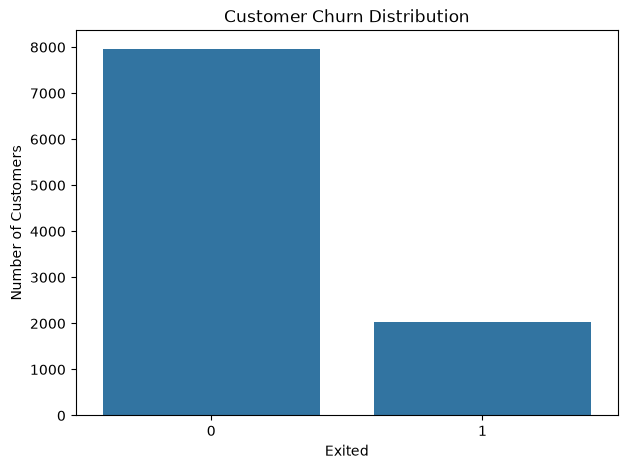

In [14]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='Exited')
plt.title('Customer Churn Distribution')
plt.xlabel('Exited')
plt.ylabel('Number of Customers')
plt.show()

In [15]:
churn_rate = df['Exited'].mean() * 100
print(f'Overall churn rate: {churn_rate:.2f}%')

Overall churn rate: 20.37%


In [16]:
geo_churn = df.groupby('Geography') ['Exited'].mean() * 100
print(geo_churn)

Geography
France     16.154767
Germany    32.443204
Spain      16.673395
Name: Exited, dtype: float64


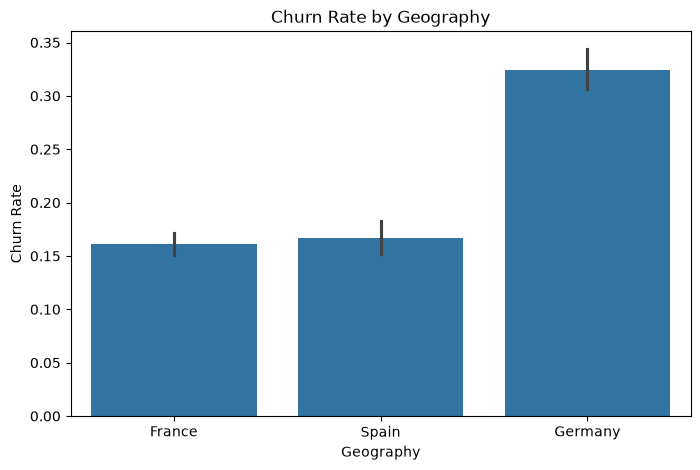

In [17]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x='Geography',
    y='Exited'
)
plt.title('Churn Rate by Geography')
plt.ylabel('Churn Rate')
plt.show()

In [18]:
gender_churn = df.groupby('Gender')['Exited'].mean() * 100
print(gender_churn)

Gender
Female    25.071539
Male      16.455928
Name: Exited, dtype: float64


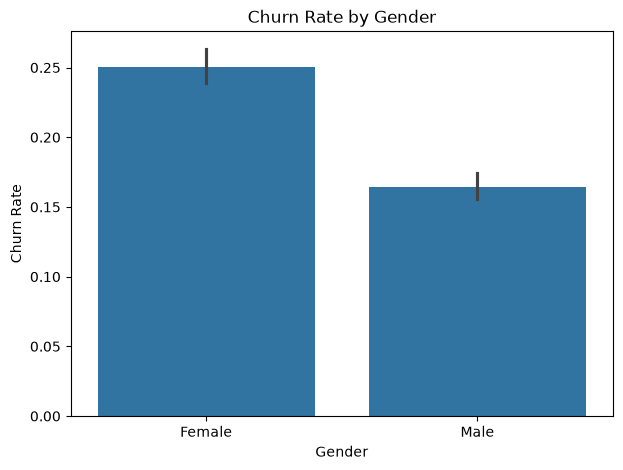

In [19]:
plt.figure(figsize=(7,5))
sns.barplot(
    data=df,
    x='Gender',
    y='Exited')
plt.title('Churn Rate by Gender')
plt.ylabel('Churn Rate')
plt.show()

In [20]:
active_churn = df.groupby('IsActiveMember')['Exited'].mean() * 100
print(active_churn)

IsActiveMember
0    26.850897
1    14.269074
Name: Exited, dtype: float64


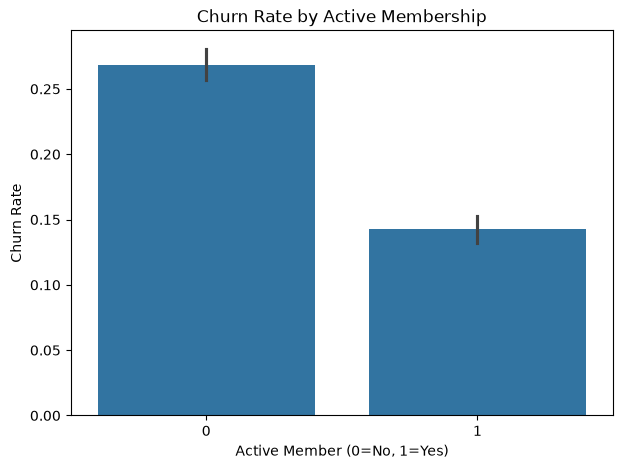

In [21]:
plt.figure(figsize=(7,5))
sns.barplot(
    data=df,
    x='IsActiveMember',
    y='Exited'
)
plt.title('Churn Rate by Active Membership')
plt.xlabel('Active Member (0=No, 1=Yes)')
plt.ylabel('Churn Rate')
plt.show()

In [22]:
product_churn = df.groupby('NumOfProducts')['Exited'].mean() * 100
print(product_churn)

NumOfProducts
1     27.714398
2      7.581699
3     82.706767
4    100.000000
Name: Exited, dtype: float64


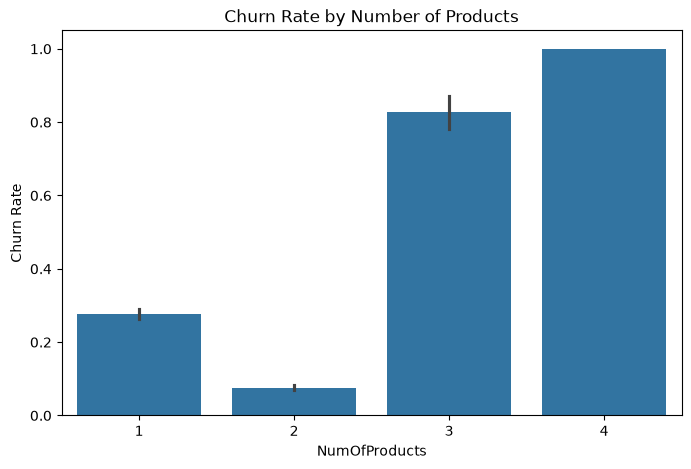

In [23]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x='NumOfProducts',
    y='Exited'
)
plt.title('Churn Rate by Number of Products')
plt.ylabel('Churn Rate')
plt.show()

In [24]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 30, 40, 50, 60, 100],
    labels=['<30', '30-40', '40-50', '50-60', '60+']
)

In [25]:
age_churn=df.groupby('AgeGroup', observed=True)['Exited'].mean() * 100
print(age_churn)

AgeGroup
<30       7.520325
30-40    12.087171
40-50    33.965517
50-60    56.210790
60+      24.784483
Name: Exited, dtype: float64


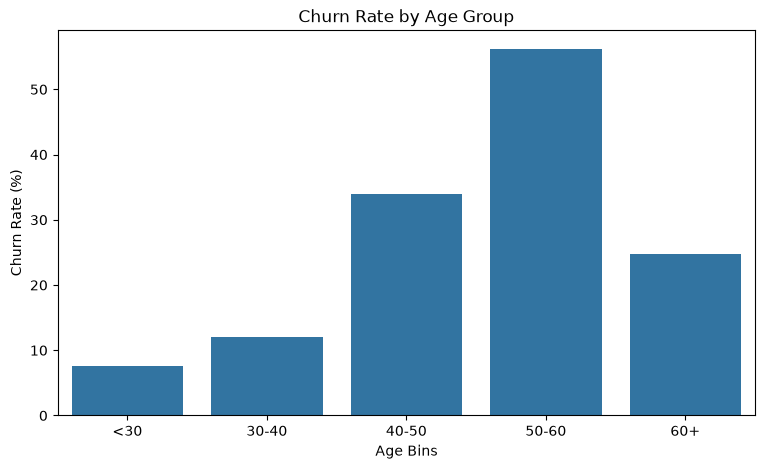

In [26]:
plt.figure(figsize=(9,5))
sns.barplot(
    x=age_churn.index,
    y=age_churn.values)
plt.title('Churn Rate by Age Group')
plt.xlabel('Age Bins')
plt.ylabel('Churn Rate (%)')
plt.show()

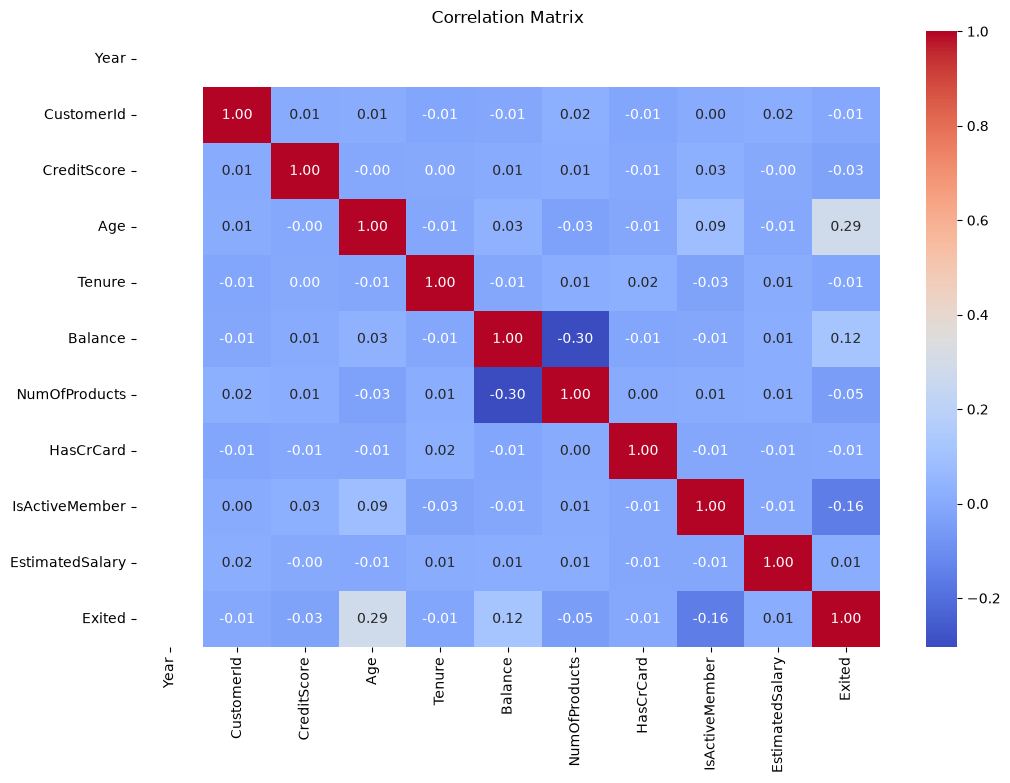

In [27]:
numeric_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(12,8))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [28]:
df['BalanceSalaryRatio'] = (
    df['Balance']/ (df['EstimatedSalary'] + 1)
)

In [29]:
df['ProductDensity'] = (
    df['NumOfProducts'] / (df['Tenure'] + 1)
)

In [30]:
df['EngagementProduct'] = (
    df['IsActiveMember'] * df['NumOfProducts']
)

In [31]:
df['AgeTenure'] = (
    df['Age'] * df['Tenure']
)

In [32]:
df[
    [
        'BalanceSalaryRatio',
        'ProductDensity',
        'EngagementProduct',
        'AgeTenure'
    ]
    ].head()

,BalanceSalaryRatio,ProductDensity,EngagementProduct,AgeTenure
0,0.000000,0.333333,1,84
1,0.744670,0.500000,1,41
2,1.401362,0.333333,0,336
3,0.000000,1.000000,0,39
4,1.587035,0.333333,1,86


In [33]:
print(df['Year'].nunique())

1


In [34]:
df['Year'].value_counts()

Year
2025    10000
Name: count, dtype: int64

In [35]:
df_model = df.drop(
    columns=['CustomerId', 'Surname', 'Year', 'AgeGroup']
)

In [36]:
x = df_model.drop('Exited', axis=1)
y = df_model['Exited']

In [37]:
print('Feature:', x.columns.tolist())
print('Target:', y.name)

Feature: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'BalanceSalaryRatio', 'ProductDensity', 'EngagementProduct', 'AgeTenure']
Target: Exited


In [38]:
categorical_features = x.select_dtypes(
    include=['object']
).columns.tolist()

In [39]:
numerical_features = x.select_dtypes(
    exclude=['object']
).columns.tolist()

In [40]:
print('Categorical features:')
print(categorical_features)
print('\nNumerical features:')
print(numerical_features)

Categorical features:
['Geography', 'Gender']

Numerical features:
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'BalanceSalaryRatio', 'ProductDensity', 'EngagementProduct', 'AgeTenure']


In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8000, 14)
Testing data: (2000, 14)


In [42]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_features),
        (
            'cat',
            OneHotEncoder(
                drop='first',
                handle_unknown='ignore'
            ),
            categorical_features
        )
    ]
)

In [43]:
logistic_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'classifier',
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['CreditScore','Geography','Gender',...,'ProductDensity', 'EngagementProduct','AgeTenure']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remaind

In [44]:
lr_pred = logistic_model.predict(X_test)
lr_prob = logistic_model.predict_proba(X_test)[:, 1]


In [45]:
decision_tree = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'classifier',
            DecisionTreeClassifier(
                max_depth=5,
                random_state=42
            )
        )
    ]
)
decision_tree.fit(X_train, y_train)
dt_pred = decision_tree.predict(X_test)
dt_prob = decision_tree.predict_proba(X_test)[:, 1]

In [46]:
random_forest=Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'classifier',
            RandomForestClassifier(
                n_estimators=300,
                max_depth=10,
                random_state=42,
                class_weight='balanced'
            )
        )
    ]
)
random_forest.fit(X_train, y_train)
rf_pred = random_forest.predict(X_test)
rf_prob = random_forest.predict_proba(X_test)[:,1]

In [47]:
gradient_boosting = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'classifier',
            GradientBoostingClassifier(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ]
)
gradient_boosting.fit(X_train, y_train)
gb_pred = gradient_boosting.predict(X_test)
gb_prob = gradient_boosting.predict_proba(X_test)[:, 1]

In [48]:
def evaluate_model(model_name, y_true, predictions, probabilities):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, predictions),
        'Precision': precision_score(y_true, predictions),
        'Recall': recall_score(y_true, predictions),
        'F1-Score': f1_score(y_true, predictions),
        'ROC-AUC': roc_auc_score(y_true, probabilities)
    }

In [49]:
results = []
results.append(
    evaluate_model(
        'Logistic Regression',
        y_test,
        lr_pred,
        lr_prob
    )
)
results.append(
    evaluate_model(
        'Decision Tree',
        y_test,
        dt_pred,
        dt_prob
    )
)
results.append(
    evaluate_model(
        'Random Forest',
        y_test,
        rf_pred,
        rf_prob
    )
)
results.append(
    evaluate_model(
        'Gradient Boostings',
        y_test,
        gb_pred,
        gb_prob
    )
)

In [50]:
results_df = pd.DataFrame(results)
results_df.sort_values(
    by='ROC-AUC',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
3,Gradient Boostings,0.8695,0.789683,0.488943,0.603945,0.869247
2,Random Forest,0.8215,0.546992,0.714988,0.619808,0.865110
1,Decision Tree,0.8570,0.795122,0.400491,0.532680,0.844181
0,Logistic Regression,0.8060,0.570370,0.189189,0.284133,0.773485


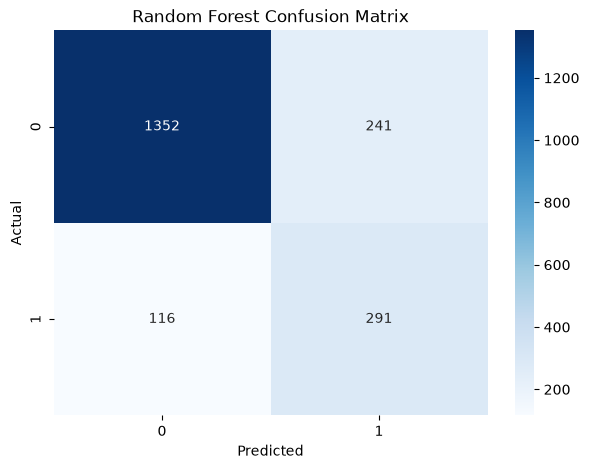

In [51]:
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(7,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [52]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.92      0.85      0.88      1593
           1       0.55      0.71      0.62       407

    accuracy                           0.82      2000
   macro avg       0.73      0.78      0.75      2000
weighted avg       0.84      0.82      0.83      2000



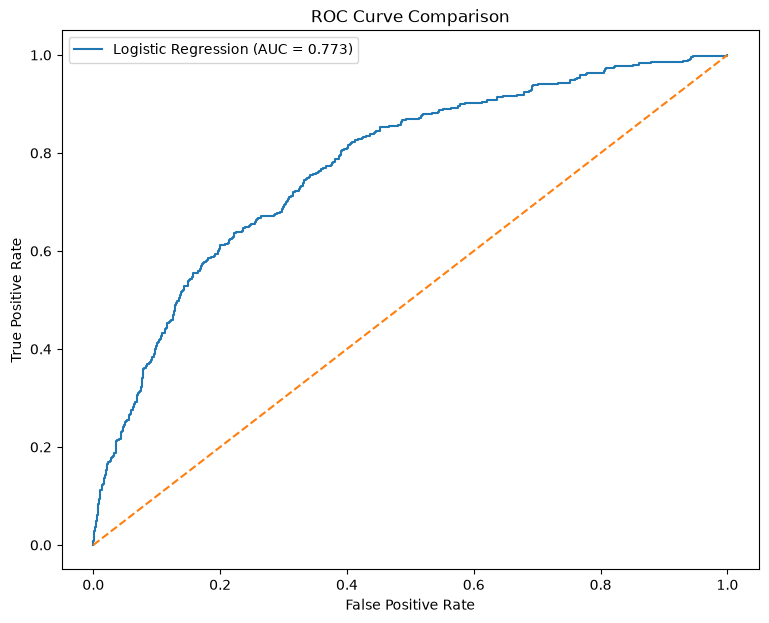

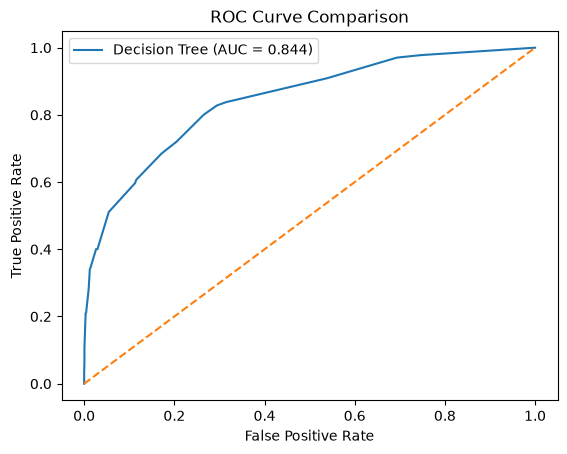

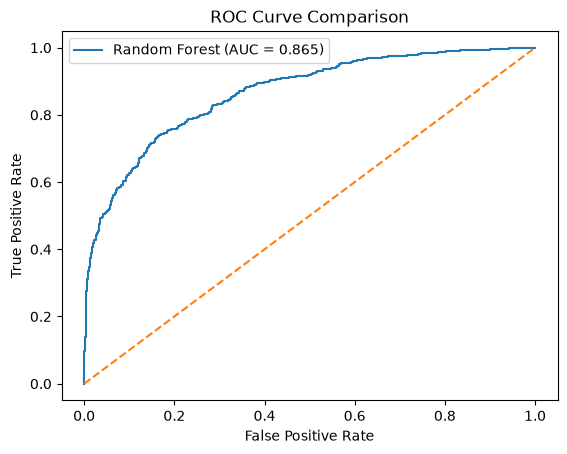

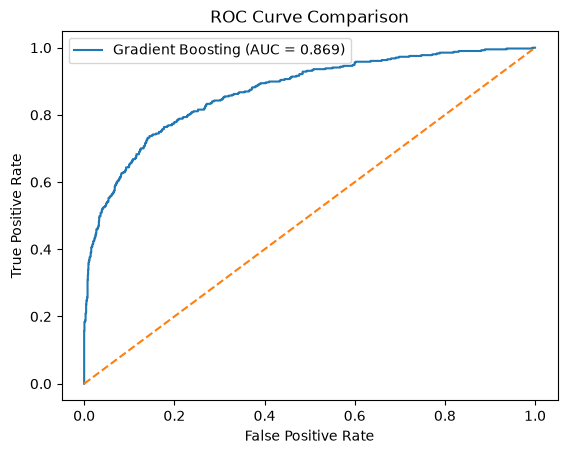

In [53]:
models_probabilities = {
    'Logistic Regression': lr_prob,
    'Decision Tree': dt_prob,
    'Random Forest': rf_prob,
    'Gradient Boosting': gb_prob
}
plt.figure(figsize=(9,7))
for name, probabilities in models_probabilities.items():
    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities
    )
    auc=roc_auc_score(
    y_test,
    probabilities
    )
    plt.plot(
    fpr,
    tpr,
    label=f'{name} (AUC = {auc:.3f})'
    )
    plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
    )
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve Comparison')
    plt.legend()
    plt.show()

In [54]:
customer_predictions = X_test.copy()
customer_predictions['Actual_Churn']=y_test.values
customer_predictions['Churn_Probability']=rf_prob
customer_predictions['Predicted_Chur']=rf_pred
customer_predictions.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,BalanceSalaryRatio,ProductDensity,EngagementProduct,AgeTenure,Actual_Churn,Churn_Probability,Predicted_Chur
5702,585,France,Male,36,7,0.00,2,1,0,94283.09,0.000000,0.250000,0,252,0,0.089435,0
3667,525,Germany,Male,33,4,131023.76,2,0,0,55072.93,2.379052,0.400000,0,132,0,0.301920,0
1617,557,Spain,Female,40,4,0.00,2,0,1,105433.53,0.000000,0.400000,2,160,0,0.098246,0
5673,639,Spain,Male,34,5,139393.19,2,0,0,33950.08,4.105707,0.333333,0,170,0,0.191532,0
4272,640,Spain,Female,34,3,77826.80,1,1,1,168544.85,0.461754,0.250000,1,102,0,0.334791,0


In [55]:
def risk_category(probability):

    if probability < 0.30:
        return "Low Risk"

    elif probability < 0.60:
        return "Medium Risk"

    else:
        return "High Risk"

In [56]:
customer_predictions["Risk_Category"] = (
    customer_predictions["Churn_Probability"]
    .apply(risk_category)
)

In [57]:
customer_predictions['Risk_Category'].value_counts()

Risk_Category
Low Risk       934
Medium Risk    707
High Risk      359
Name: count, dtype: int64

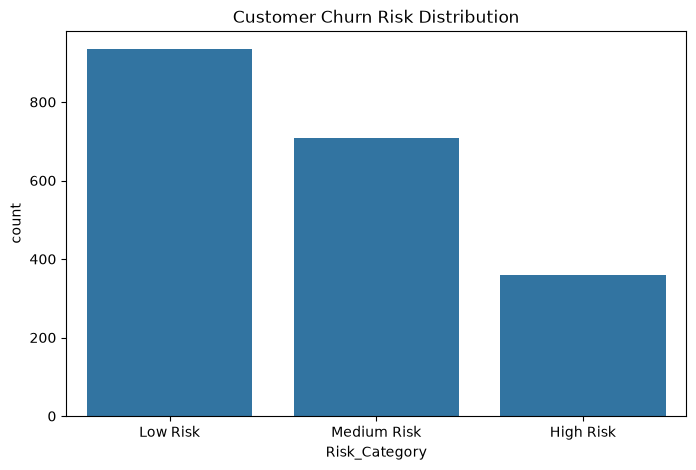

In [58]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=customer_predictions,
    x='Risk_Category',
    order=[
        'Low Risk',
        'Medium Risk',
        'High Risk'
    ]
)
plt.title('Customer Churn Risk Distribution')
plt.show()

In [59]:
feature_names=(
    random_forest
    .named_steps['preprocessor']
    .get_feature_names_out()
)

In [60]:
importance = (
    random_forest
    .named_steps['classifier']
    .feature_importances_
)

In [61]:
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})
feature_importance=(
    feature_importance
    .sort_values(
        by='Importance',
        ascending=False
    )
)

In [62]:
feature_importance.head(15)

,Feature,Importance
1,num__Age,0.269006
4,num__NumOfProducts,0.152951
10,num__EngagementProduct,0.078434
3,num__Balance,0.077292
11,num__AgeTenure,0.067906
8,num__BalanceSalaryRatio,0.057460
7,num__EstimatedSalary,0.054110
0,num__CreditScore,0.052698
12,cat__Geography_Germany,0.046743
9,num__ProductDensity,0.046553


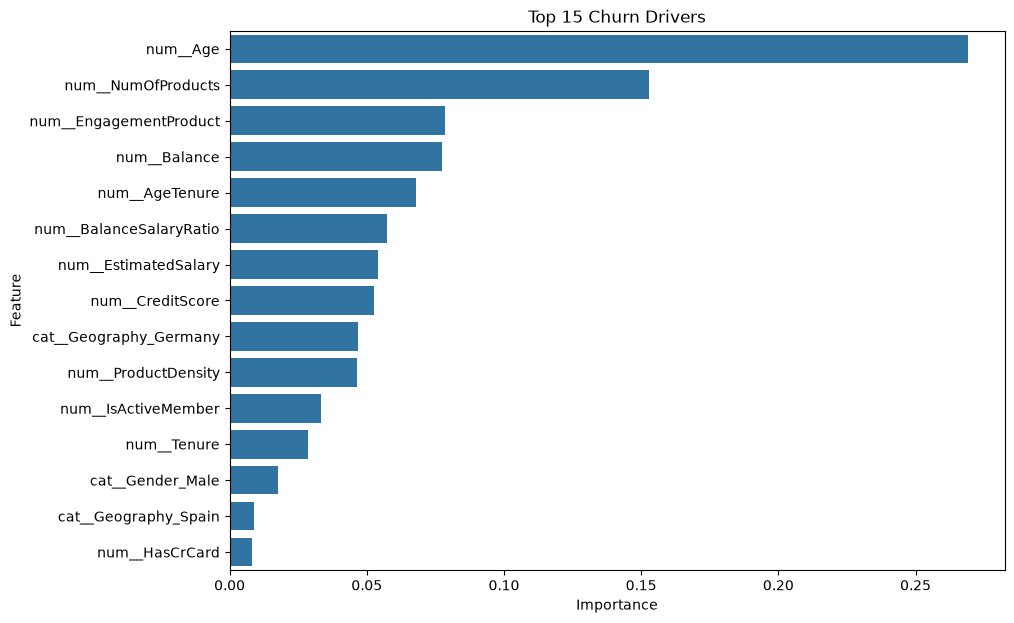

In [63]:
plt.figure(figsize=(10,7))
sns.barplot(
    data=feature_importance.head(15),
    x='Importance',
y='Feature'
)
plt.title('Top 15 Churn Drivers')
plt.show()

In [64]:
import shap


In [65]:
X_train_transformed=(
    random_forest
    .named_steps['preprocessor']
    .transform(X_train)
)
X_test_transformed=(
    random_forest
    .named_steps['preprocessor']
    .transform(X_test)
)

In [66]:
rf_classifier=(
    random_forest
    .named_steps['classifier']
)
explainer=shap.TreeExplainer(
    rf_classifier
)

In [67]:
shap_values = explainer.shap_values(
    X_test_transformed
)

In [68]:
if isinstance(shap_values, list):
    shap_values_churn = shap_values[1]
else:
    shap_values_churn = shap_values

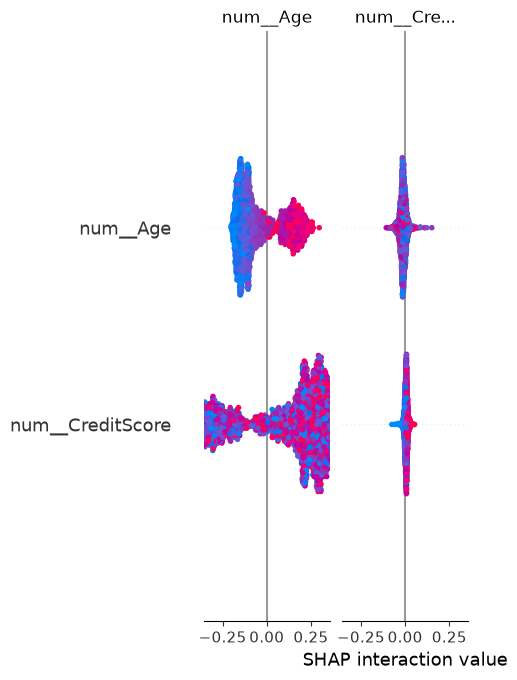

In [69]:
shap.summary_plot(
    shap_values_churn,
    X_test_transformed,
    feature_names=feature_names
)

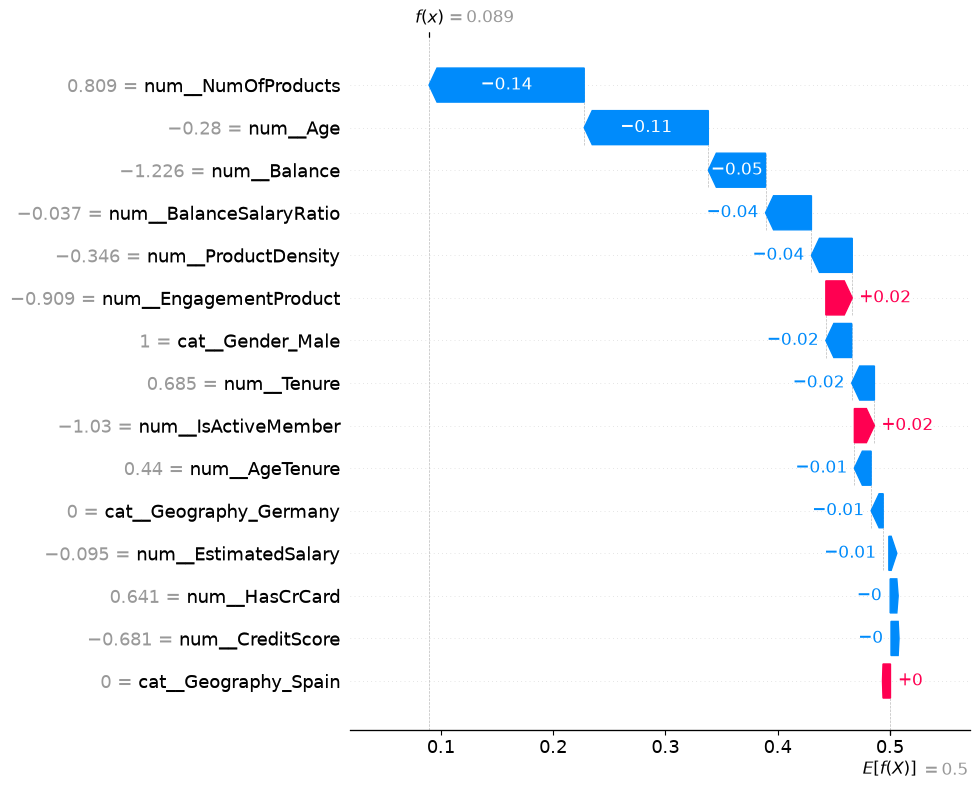

In [70]:
customer_index = 0

if len(shap_values.shape) == 3:
    customer_shap_values = shap_values[customer_index, :, 1]
else:
    customer_shap_values = shap_values_churn[customer_index]

if isinstance(explainer.expected_value, np.ndarray):
    customer_base_value = explainer.expected_value[1]
else:
    customer_base_value = explainer.expected_value

shap_explanation = shap.Explanation(
    values=customer_shap_values,
    base_values=customer_base_value,
    data=X_test_transformed[customer_index],
    feature_names=feature_names
)

shap.plots.waterfall(
    shap_explanation,
    max_display=15
)

In [71]:
from sklearn.inspection import PartialDependenceDisplay

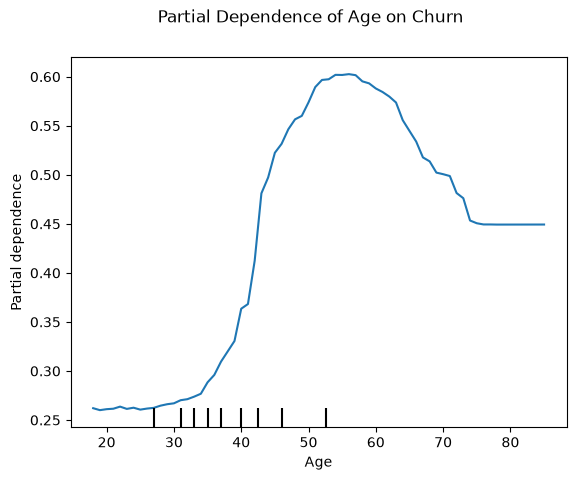

In [72]:
X_test_pdp = X_test.copy()

for col in numerical_features:
    X_test_pdp[col] = X_test_pdp[col].astype(float)

from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(
    random_forest,
    X_test_pdp,
    ["Age"]
)

plt.suptitle("Partial Dependence of Age on Churn")
plt.show()

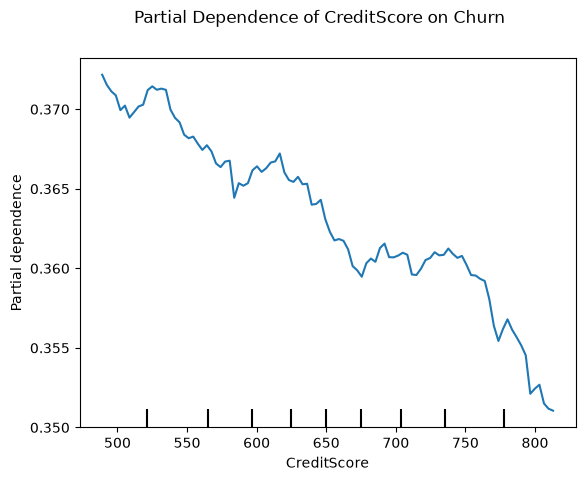

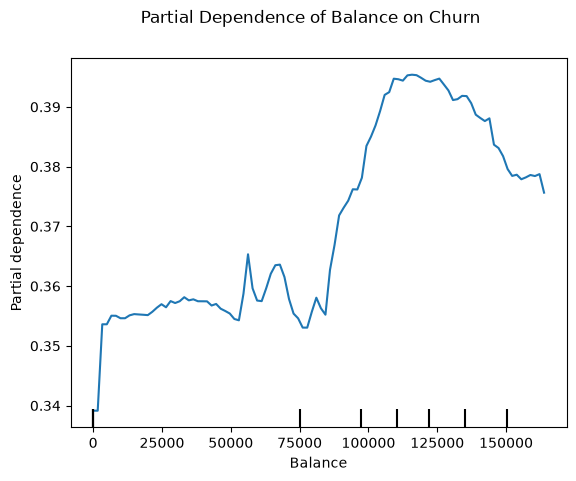

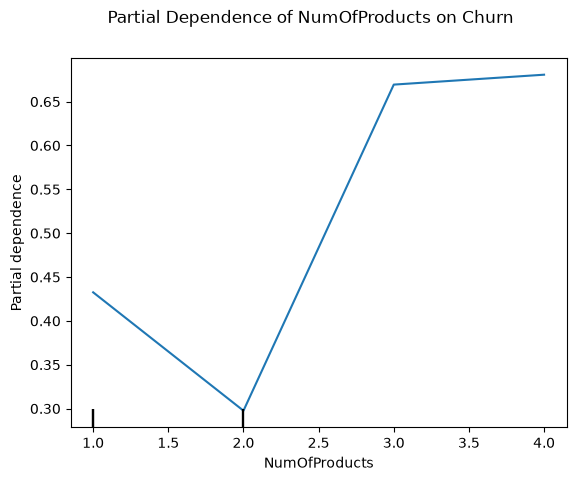

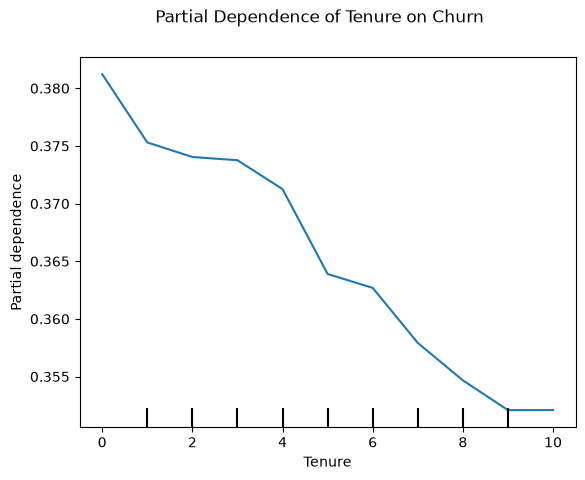

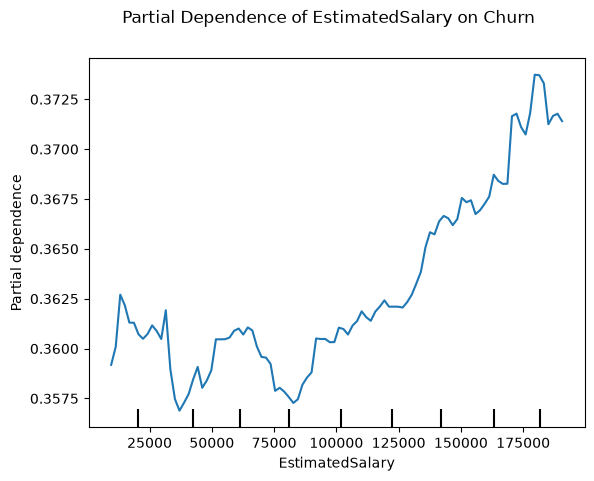

In [73]:
features_for_pdp = [
    "CreditScore",
    "Balance",
    "NumOfProducts",
    "Tenure",
    "EstimatedSalary"
]

for feature in features_for_pdp:

    PartialDependenceDisplay.from_estimator(
        random_forest,
        X_test_pdp,
        [feature]
    )

    plt.suptitle(
        f"Partial Dependence of {feature} on Churn"
    )

    plt.show()

In [74]:
cv= StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [75]:
cv_scores = cross_val_score(
    random_forest,
    x,
    y,
    cv=cv,
    scoring='roc_auc'
)
print('Cross-validation ROC-AUC scores:')
print(cv_scores)
print(f'\nMean ROC-AUC: {cv_scores.mean():.3f}')
print(f'Standard deviation: {cv_scores.mean():.3f}')

Cross-validation ROC-AUC scores:
[0.86202458 0.84677986 0.85729335 0.86263768 0.8727757 ]

Mean ROC-AUC: 0.860
Standard deviation: 0.860


In [76]:
print('Mean CV ROC-AUC:', cv_scores.mean())
print('Standard Deviation:', cv_scores.std())

Mean CV ROC-AUC: 0.860302233432184
Standard Deviation: 0.008437017652158516


In [77]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

threshold_results = []

for threshold in thresholds:

    predictions = (rf_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1-Score": f1_score(y_test, predictions, zero_division=0),
        "False Positives": fp,
        "False Negatives": fn,
        "True Positives": tp,
        "True Negatives": tn
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Accuracy,Precision,Recall,F1-Score,False Positives,False Negatives,True Positives,True Negatives
0,0.3,0.6335,0.347092,0.909091,0.502376,696,37,370,897
1,0.4,0.7490,0.436412,0.800983,0.564991,421,81,326,1172
2,0.5,0.8215,0.546992,0.714988,0.619808,241,116,291,1352
3,0.6,0.8540,0.660167,0.582310,0.618799,122,170,237,1471
4,0.7,0.8665,0.767176,0.493857,0.600897,61,206,201,1532


In [78]:
best_threshold_row = threshold_df.loc[
    threshold_df['F1-Score'].idxmax()
    ]
best_threshold = best_threshold_row['Threshold']
print('Best Threshold:', best_threshold)
print('Best F1-Score:', best_threshold_row['F1-Score'])

Best Threshold: 0.5
Best F1-Score: 0.6198083067092651


In [79]:
fp_reduction_df = threshold_df.sort_values(
    by='False Positives',
    ascending=True
)
fp_reduction_df

,Threshold,Accuracy,Precision,Recall,F1-Score,False Positives,False Negatives,True Positives,True Negatives
4,0.7,0.8665,0.767176,0.493857,0.600897,61,206,201,1532
3,0.6,0.8540,0.660167,0.582310,0.618799,122,170,237,1471
2,0.5,0.8215,0.546992,0.714988,0.619808,241,116,291,1352
1,0.4,0.7490,0.436412,0.800983,0.564991,421,81,326,1172
0,0.3,0.6335,0.347092,0.909091,0.502376,696,37,370,897


In [80]:
lowest_fp_row=threshold_df.loc[
    threshold_df['False Positives'].idxmin()
    ]
print('Threshold with lowest false positives:',
      lowest_fp_row['Threshold'])
print('False Positives:',
      lowest_fp_row['False Positives'])
print('Precision:',
      lowest_fp_row['Precision'])
print('Recall:',
      lowest_fp_row['Recall'])

Threshold with lowest false positives: 0.7
False Positives: 61.0
Precision: 0.767175572519084
Recall: 0.49385749385749383


<module 'matplotlib.pyplot' from '/Users/vardaraj/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/matplotlib/pyplot.py'>

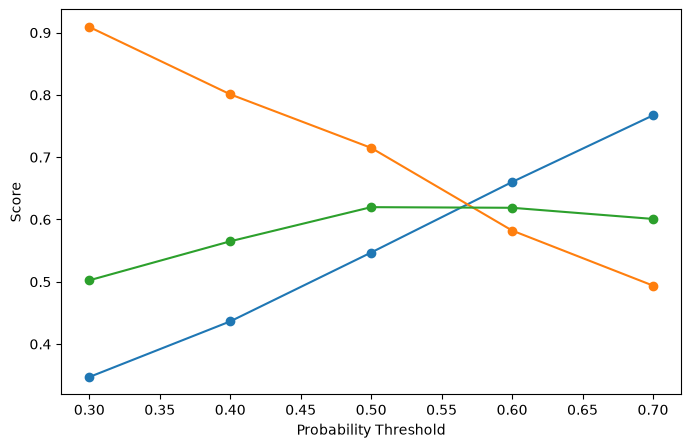

In [81]:
plt.figure(figsize=(8, 5))
plt.plot(
    threshold_df['Threshold'],
    threshold_df['Precision'],
    marker='o',
    label='Precision'
)
plt.plot(
    threshold_df['Threshold'],
    threshold_df['Recall'],
    marker='o',
    label='Recall'
)
plt.plot(
    threshold_df['Threshold'],
    threshold_df['F1-Score'],
    marker='o',
    label='F1-Score')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt

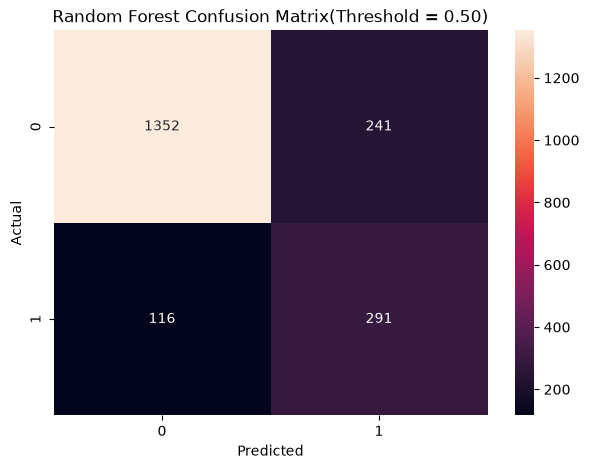

In [82]:
optimized_predictions = (
    rf_prob>= best_threshold).astype(int)
cm_optimized =confusion_matrix(
    y_test,
    optimized_predictions)
plt.figure(figsize=(7,5))
sns.heatmap(
    cm_optimized,
    annot=True,
    fmt='d')
plt.title(
    f'Random Forest Confusion Matrix'
    f'(Threshold = {best_threshold:.2f})'
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [83]:
customer = X_test.iloc[[0]].copy()

In [84]:
customer
current_probability=random_forest.predict_proba(
    customer
)[:, 1][0]
print(
    f'Current churn probability:'
    f'{current_probability:.2%}'
)

Current churn probability:8.94%


In [85]:
active_scenario = customer.copy()
active_scenario['IsActiveMember']=1
scenario_probability= random_forest.predict_proba(
    active_scenario
)[:, 1][0]
print(
    f'Chur probability after becoming active:'
    f'{scenario_probability:.2%}')

Chur probability after becoming active:11.38%


In [86]:
scenario_comparison = pd.DataFrame({
    "Scenario": [
        "Current Customer",
        "Active Member Scenario"
    ],
    "Churn Probability": [
        current_probability,
        scenario_probability
    ]
})

scenario_comparison["Churn Probability"] = (
    scenario_comparison["Churn Probability"] * 100
)

scenario_comparison

,Scenario,Churn Probability
0,Current Customer,8.943480
1,Active Member Scenario,11.375709


In [87]:
probability_change=(
    scenario_probability - current_probability
)
print(
    f'Change in churn probability:'
    f'{probability_change:.2%}')

Change in churn probability:2.43%


In [88]:
product_scenario = customer.copy()
product_scenario['NumOfProducts']=2
product_probability= random_forest.predict_proba(
    product_scenario
)[:, 1][0]
print(
    f'Original churn probability:'
    f'{current_probability:.2%}'
)
print(
    f'Churn probability with 2 products:'
    f'{product_probability:.2%}'
)
print(
    f'Change:'
    f'{product_probability - current_probability:.2%}'
)

Original churn probability:8.94%
Churn probability with 2 products:8.94%
Change:0.00%


In [89]:
scenario_results = pd.DataFrame({
    'Scenario':[
        'Current Customer',
        'Active Member',
        '2 Products'
    ],
    'Churn Probability':[
        current_probability,
        scenario_probability,
        product_probability]})
scenario_results['Churn Probability (%)'] = (
    scenario_results['Churn Probability'] * 100)
scenario_results

,Scenario,Churn Probability,Churn Probability (%)
0,Current Customer,0.089435,8.943480
1,Active Member,0.113757,11.375709
2,2 Products,0.089435,8.943480


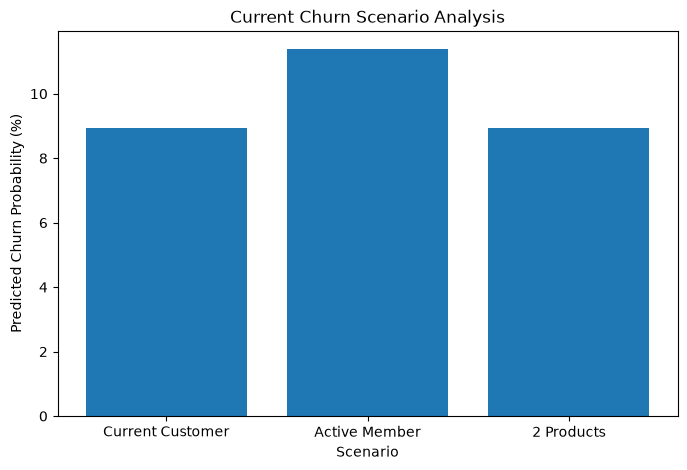

In [90]:
plt.figure(figsize=(8,5))
plt.bar(
    scenario_results['Scenario'],
    scenario_results['Churn Probability (%)']
)
plt.ylabel('Predicted Churn Probability (%)')
plt.xlabel('Scenario')
plt.title('Current Churn Scenario Analysis')
plt.show()

In [91]:
from xgboost import XGBClassifier

In [92]:
xgboost_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=4,
                random_state=42,
                eval_metric="logloss"
            )
        )
    ]
)

xgboost_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['CreditScore','Geography','Gender',...,'ProductDensity', 'EngagementProduct','AgeTenure']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remaind

In [93]:
xgb_pred = xgboost_model.predict(X_test)

xgb_prob = xgboost_model.predict_proba(
    X_test
)[:, 1]

In [94]:
xgb_results = evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred,
    xgb_prob
)

xgb_results

{'Model': 'XGBoost',
 'Accuracy': 0.8655,
 'Precision': 0.7716535433070866,
 'Recall': 0.48157248157248156,
 'F1-Score': 0.5930408472012103,
 'ROC-AUC': 0.866836790565604}

In [95]:
results_with_xgb = pd.concat(
    [
        results_df,
        pd.DataFrame([xgb_results])
    ],
    ignore_index=True
)

results_with_xgb.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
3,Gradient Boostings,0.8695,0.789683,0.488943,0.603945,0.869247
4,XGBoost,0.8655,0.771654,0.481572,0.593041,0.866837
2,Random Forest,0.8215,0.546992,0.714988,0.619808,0.865110
1,Decision Tree,0.8570,0.795122,0.400491,0.532680,0.844181
0,Logistic Regression,0.8060,0.570370,0.189189,0.284133,0.773485


In [96]:
y=df_model['Exited']

In [97]:
rf_prob = random_forest.predict_proba(X_test)[:, 1]
ref_pred = random_forest.predict(X_test)

In [98]:
customer_predictions['Churn_Probaility']=rf_prob

In [100]:
def risk_category(probability):
    if probability < 0.30:
        return 'Low Risk'
    elif probability < 0.60:
        return 'Medium Risk'
    else:
        return 'High Risk'

In [101]:
y = df_model['Exited']
rf_prob = random_forest.predict_proba(X_test)[:, 1]
rf_pred = random_forest.predict(X_test)
print("Target variable: Exited")
print("Churn probability range:", rf_prob.min(), "to", rf_prob.max())

Target variable: Exited
Churn probability range: 0.022396866062829625 to 0.9780319142643648
